Кросс-валидация, метрики и утечки данных (Data Leakage) — практикум

**Как работать:**
- Теорию вспоминаем коротко, затем сразу переходим к практическим шагам.
- Опирайтесь на примеры из `boostings_101.ipynb`, `eda-feat-engeen.ipynb` и `pandas_matplotlib:seaborn.ipynb`, но пишите код сами.
- У каждой секции есть цель и мини-задание, чтобы получился законченный эксперимент.

**Цели занятия:**
- Осознать, зачем нужна кросс-валидация и как она проверяет устойчивость модели.
- Подобрать схему CV под тип данных (обычные таблицы, дисбаланс, группы, время).
- Распознавать утечки данных и строить безопасный пайплайн.
- Уверенно считать и интерпретировать метрики классификации и регрессии.

**План:**
1. Разминка: базовый split и быстрый прогон метрик.
2. Сравниваем схемы CV: KFold, StratifiedKFold, GroupKFold, TimeSeriesSplit.
3. Data Leakage: ищем утечку и чиним её.
4. Метрики классификации.
5. Метрики регрессии.
6. Итоговая мини-практика и самооценка.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, StratifiedKFold, 
    GroupKFold, TimeSeriesSplit, LeaveOneGroupOut
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


### Практическая дорожная карта
1. **Быстрый прогон (разминка).** Соберите baseline, посмотрите на метрики.
2. **Гибкий CV.** Перепробуйте несколько схем, посмотрите, как меняется разброс качества.
3. **Охота на утечки.** Найдите подозрительные признаки/операции и проверьте, влияют ли они на валидацию.
4. **Метрики руками.** Посчитайте accuracy/precision/recall/F1/ROC-AUC и MAE/MSE/R² без готовых хелперов.
5. **Итог.** Оформите короткий отчёт: что сработало, где модель нестабильна и почему.

> Совет: перед каждым кодовым блоком сформулируйте гипотезу, а после — короткий вывод в 1–2 предложениях.


---
## 1. Зачем нужна кросс-валидация?

**Проблема:** Один train/test split может быть «удачным» или «неудачным». Оценка качества модели нестабильна.

**Решение:** Кросс-валидация — разбиваем данные на K частей (фолдов), обучаем K раз, каждый раз используя другую часть как валидационную.

**Преимущества:**
- Более стабильная оценка качества
- Используем все данные и для обучения, и для валидации
- Можем оценить дисперсию качества (насколько модель стабильна)


In [2]:
# Создаём синтетические данные для демонстрации
X, y = make_classification(
    n_samples=1000, n_features=20, n_informative=10,
    n_redundant=5, n_classes=2, random_state=RANDOM_STATE
)

print(f"Размер данных: {X.shape}")
print(f"Распределение классов: {np.bincount(y)}")


Размер данных: (1000, 20)
Распределение классов: [497 503]


In [3]:
# Простой train/test split — одна оценка
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

model = LogisticRegression(random_state=RANDOM_STATE)
model.fit(X_train, y_train)
single_score = model.score(X_test, y_test)

print(f"Accuracy на одном split: {single_score:.4f}")


Accuracy на одном split: 0.7950


In [4]:
# Кросс-валидация — K оценок
cv_scores = cross_val_score(
    LogisticRegression(random_state=RANDOM_STATE), 
    X, y, cv=5, scoring='accuracy'
)

print(f"CV scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


CV scores: [0.855 0.86  0.86  0.805 0.825]
Mean: 0.8410 ± 0.0222


**Вывод:** CV даёт не только среднее качество, но и понимание стабильности модели (через std).

---
## 2. Схемы кросс-валидации

Не все данные одинаковы! Выбор схемы CV зависит от структуры данных.

| Схема | Когда использовать |
|-------|-------------------|
| `KFold` | Регрессия, данные i.i.d. |
| `StratifiedKFold` | Классификация (сохраняет пропорции классов) |
| `GroupKFold` | Данные сгруппированы (один пользователь = одна группа) |
| `TimeSeriesSplit` | Временные ряды (нельзя «подглядывать в будущее») |

### 2.1 KFold — базовая схема


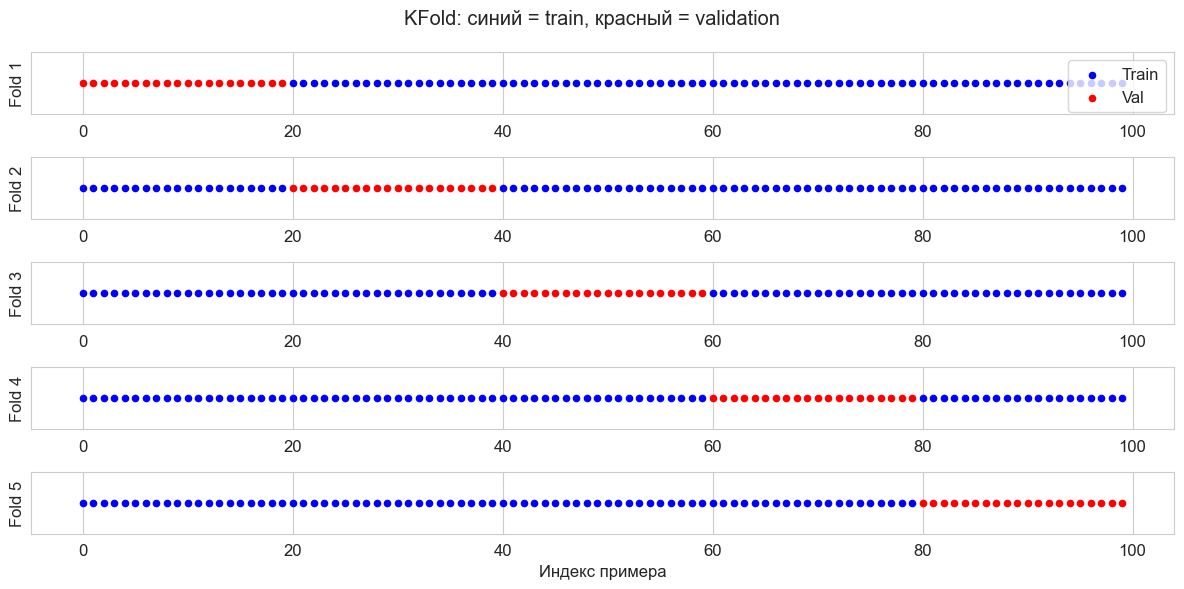

In [9]:
# Визуализация KFold
kfold = KFold(n_splits=5)

fig, axes = plt.subplots(5, 1, figsize=(12, 6))
sample_indices = np.arange(100)  # Берём первые 100 примеров для визуализации

for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(sample_indices)):
    ax = axes[fold_idx]
    ax.scatter(train_idx, [1]*len(train_idx), c='blue', s=20, label='Train')
    ax.scatter(val_idx, [1]*len(val_idx), c='red', s=20, label='Val')
    ax.set_ylabel(f'Fold {fold_idx+1}')
    ax.set_yticks([])
    if fold_idx == 0:
        ax.legend(loc='upper right')

plt.xlabel('Индекс примера')
plt.suptitle('KFold: синий = train, красный = validation')
plt.tight_layout()
plt.show()


### 2.2 StratifiedKFold — для классификации

**Проблема:** При обычном KFold в каком-то фолде может оказаться только один класс (особенно при несбалансированных данных).

**Решение:** StratifiedKFold сохраняет пропорции классов в каждом фолде.


In [10]:
# Создаём несбалансированные данные
X_imb, y_imb = make_classification(
    n_samples=200, n_features=10, n_classes=2,
    weights=[0.9, 0.1],  # 90% класс 0, 10% класс 1
    random_state=RANDOM_STATE
)

print(f"Распределение классов: {np.bincount(y_imb)}")
print(f"Доля класса 1: {y_imb.mean():.2%}")


Распределение классов: [180  20]
Доля класса 1: 10.00%


**Вывод:** StratifiedKFold сохраняет пропорции ~10% в каждом фолде. Для классификации — это стандартный выбор!

### 2.3 GroupKFold — когда есть группы

**Проблема:** Если один пользователь встречается и в train, и в val — модель может «запомнить» пользователя, а не научиться обобщать.

**Пример:** Распознавание лиц. Если фото одного человека есть в train и test — модель может просто запомнить лицо.

**Решение:** GroupKFold — все примеры одной группы попадают либо только в train, либо только в val.


In [11]:
# Симулируем данные с группами (например, user_id)
n_samples = 100
n_users = 10

X_grouped = np.random.randn(n_samples, 5)
y_grouped = np.random.randint(0, 2, n_samples)
groups = np.repeat(np.arange(n_users), n_samples // n_users)  # 10 примеров на пользователя

print(f"Группы (user_id): {groups}")


Группы (user_id): [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3
 3 3 3 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 7 7 7 7
 7 7 7 7 7 7 8 8 8 8 8 8 8 8 8 8 9 9 9 9 9 9 9 9 9 9]


In [12]:
# GroupKFold: пользователь целиком в train или val
group_kfold = GroupKFold(n_splits=5)

print("=== GroupKFold ===")
for fold_idx, (train_idx, val_idx) in enumerate(group_kfold.split(X_grouped, y_grouped, groups)):
    train_groups = set(groups[train_idx])
    val_groups = set(groups[val_idx])
    overlap = train_groups & val_groups
    print(f"Fold {fold_idx+1}: train groups = {sorted(train_groups)}, val groups = {sorted(val_groups)}")
    print(f"         Пересечение: {overlap if overlap else 'нет (✓)'}")


=== GroupKFold ===
Fold 1: train groups = [0, 1, 2, 3, 5, 6, 7, 8], val groups = [4, 9]
         Пересечение: нет (✓)
Fold 2: train groups = [0, 1, 2, 4, 5, 6, 7, 9], val groups = [3, 8]
         Пересечение: нет (✓)
Fold 3: train groups = [0, 1, 3, 4, 5, 6, 8, 9], val groups = [2, 7]
         Пересечение: нет (✓)
Fold 4: train groups = [0, 2, 3, 4, 5, 7, 8, 9], val groups = [1, 6]
         Пересечение: нет (✓)
Fold 5: train groups = [1, 2, 3, 4, 6, 7, 8, 9], val groups = [0, 5]
         Пересечение: нет (✓)


### 2.4 TimeSeriesSplit — для временных рядов

**Проблема:** Во временных данных нельзя «подглядывать в будущее». Обычный KFold это нарушает.

**Решение:** TimeSeriesSplit — train всегда до val по времени.


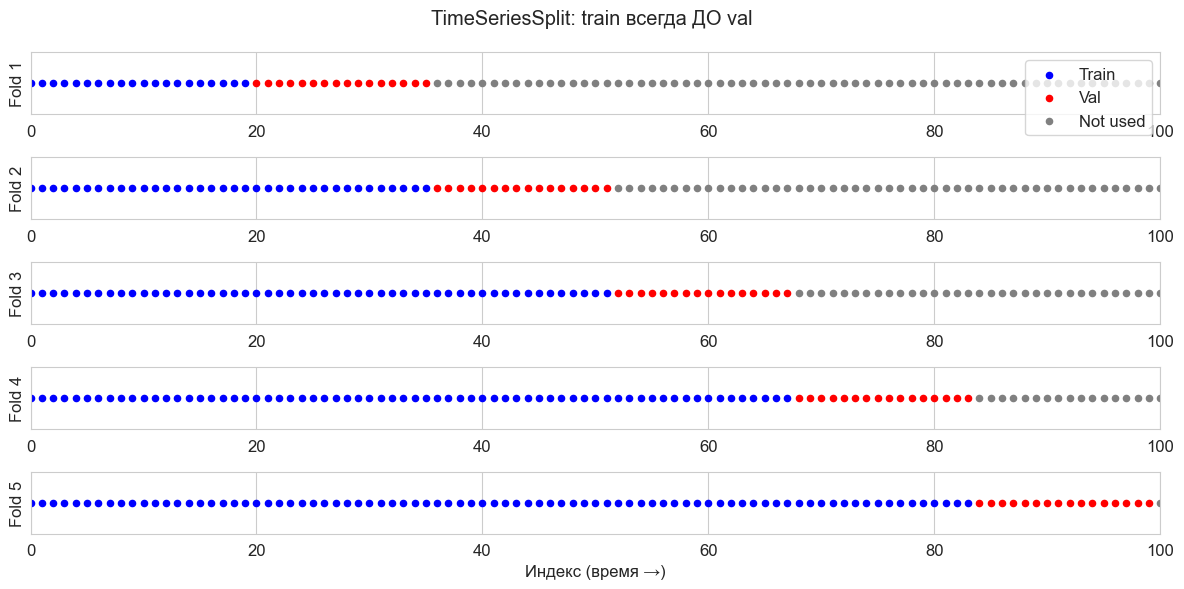

In [21]:
# Симулируем временной ряд
dates = pd.date_range('2023-01-01', periods=100, freq='D')
X_ts = np.arange(100).reshape(-1, 1)  # Простой индекс как "фича"
y_ts = np.random.randn(100)

# Визуализация TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

fig, axes = plt.subplots(5, 1, figsize=(12, 6))

for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_ts)):
    ax = axes[fold_idx]
    ax.scatter(train_idx, [1]*len(train_idx), c='blue', s=20, label='Train')
    ax.scatter(val_idx, [1]*len(val_idx), c='red', s=20, label='Val')
    ax.scatter(np.arange(val_idx.max() + 1, 101), [1]*(101 - len(train_idx) - len(val_idx)), c='grey', s=20, label='Not used')
    ax.set_ylabel(f'Fold {fold_idx+1}')
    ax.set_yticks([])
    ax.set_xlim(0, 100)
    if fold_idx == 0:
        ax.legend(loc='upper right')

plt.xlabel('Индекс (время →)')
plt.suptitle('TimeSeriesSplit: train всегда ДО val')
plt.tight_layout()
plt.show()


**Важно:** В TimeSeriesSplit train растёт с каждым фолдом. Это имитирует реальную ситуацию: «обучаемся на прошлом, предсказываем будущее».

---
### Упражнение 1: Выбор схемы CV

Для каждой ситуации выберите подходящую схему CV:


### Практика: соберите честный CV под свой сценарий
- Выберите одну схему из списка ниже и аргументируйте выбор.
- Заполните TODO так, чтобы получить среднее качество и стандартное отклонение.
- Сравните с базовым train/test split: стало ли стабильнее?


In [ ]:
# TODO: реализуйте функцию evaluate_model с выбранной схемой CV
# 1) Принимает модель, данные и схему CV
# 2) Возвращает среднее качество и разброс
# Подсказка: используйте cross_val_score или цикл по splits

# def evaluate_model(model, X, y, cv):
#     ...

# your_mean, your_std = evaluate_model(...)
# print(f"Mean={your_mean:.3f}, std={your_std:.3f}")


In [ ]:
# TODO: Заполните словарь правильными ответами
# Варианты: 'KFold', 'StratifiedKFold', 'GroupKFold', 'TimeSeriesSplit'

answers = {
    'Классификация спама в email': ...,  # Ваш ответ
    'Предсказание цены акций': ...,  # Ваш ответ
    'Распознавание эмоций по фото (несколько фото одного человека)': ...,  # Ваш ответ
    'Регрессия цены дома (данные перемешаны)': ...,  # Ваш ответ
}


<details style="margin: 10px 0;">
  <summary style="
    font-size: 16px;
    color: #1f2937;
    background: #eef2ff;
    padding: 6px 10px;
    border-radius: 8px;
    cursor: pointer;
    display: inline-block;
    user-select: none;
    border: 1px solid #c7d2fe;
  ">
    ▸ Показать решение
  </summary>

    - 'Классификация спама в email': 'StratifiedKFold'
    - 'Предсказание цены акций': 'TimeSeriesSplit'
    - 'Распознавание эмоций по фото (несколько фото одного человека)': 'GroupKFold'
    - 'Регрессия цены дома (данные перемешаны)': 'KFold'

</details>

---
## 3. Data Leakage (утечки данных)

**Data Leakage** — когда информация из тестовых данных «просачивается» в обучение. Результат: модель показывает отличные метрики на валидации, но плохо работает в продакшене.

**Типичные причины утечек:**

1. **Предобработка до split** — fit scaler/encoder на всех данных, потом split
2. **Target leakage** — признак, который содержит информацию о таргете (известен только после события)
3. **Временная утечка** — использование будущих данных для предсказания прошлого

### 3.1 Пример утечки через предобработку


In [22]:
# Создаём данные
X_leak, y_leak = make_classification(
    n_samples=200, n_features=20, n_informative=5,
    random_state=RANDOM_STATE
)

# ❌ НЕПРАВИЛЬНО: fit scaler на ВСЕХ данных до split
scaler_wrong = StandardScaler()
X_scaled_wrong = scaler_wrong.fit_transform(X_leak)  # Утечка!

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_scaled_wrong, y_leak, test_size=0.3, random_state=RANDOM_STATE
)

model_wrong = LogisticRegression(random_state=RANDOM_STATE)
model_wrong.fit(X_train_w, y_train_w)
score_wrong = model_wrong.score(X_test_w, y_test_w)
print(f"❌ С утечкой: Accuracy = {score_wrong:.4f}")


❌ С утечкой: Accuracy = 0.7333


In [23]:
# ✅ ПРАВИЛЬНО: сначала split, потом fit scaler только на train
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_leak, y_leak, test_size=0.3, random_state=RANDOM_STATE
)

scaler_right = StandardScaler()
X_train_scaled = scaler_right.fit_transform(X_train_r)  # fit только на train!
X_test_scaled = scaler_right.transform(X_test_r)  # transform на test

model_right = LogisticRegression(random_state=RANDOM_STATE)
model_right.fit(X_train_scaled, y_train_r)
score_right = model_right.score(X_test_scaled, y_test_r)
print(f"✅ Без утечки: Accuracy = {score_right:.4f}")


✅ Без утечки: Accuracy = 0.7333


<details style="margin: 10px 0;">
  <summary style="
    font-size: 16px;
    color: #1f2937;
    background: #eef2ff;
    padding: 6px 10px;
    border-radius: 8px;
    cursor: pointer;
    display: inline-block;
    user-select: none;
    border: 1px solid #c7d2fe;
  ">
    ▸Почему это важно?
  </summary>

В этом примере разницы нет, но на реальных данных:
- Scaler «знает» статистики test данных (mean, std)
- Это особенно критично для target encoding, imputation и т.д.

**Решение:** Использовать `sklearn.pipeline.Pipeline` (см. ноутбук `02_sklearn_pipelines.ipynb`)

</details>





### 3.2 Пример Target Leakage


In [24]:
# Пример: предсказываем, купит ли клиент товар
# Утечка: признак "дата доставки" — известен только ПОСЛЕ покупки!

np.random.seed(RANDOM_STATE)
n = 1000

df_leak = pd.DataFrame({
    'age': np.random.randint(18, 65, n),
    'income': np.random.randint(20000, 150000, n),
    'days_since_last_visit': np.random.randint(0, 365, n),
    'bought': np.random.randint(0, 2, n)  # Таргет
})

# Добавляем "утекающий" признак: дата доставки (есть только если bought=1)
df_leak['delivery_days'] = np.where(
    df_leak['bought'] == 1,
    np.random.randint(1, 14, n),  # Если купил — есть дата доставки
    0  # Если не купил — 0
)

print("Данные с утечкой (delivery_days):")
print(df_leak.head(10))


Данные с утечкой (delivery_days):
   age  income  days_since_last_visit  bought  delivery_days
0   56  136748                    225       1             13
1   46   25287                    284       1              5
2   32  146593                      3       1             10
3   60   54387                     98       0              0
4   25   28512                     38       0              0
5   38   21342                    270       1             13
6   56   83076                    284       0              0
7   36  128872                    156       0              0
8   40   39216                     74       0              0
9   28  137512                    287       1              5


In [25]:
# Модель с утечкой
X_with_leak = df_leak[['age', 'income', 'days_since_last_visit', 'delivery_days']]
y_target = df_leak['bought']

cv_scores_leak = cross_val_score(
    RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE),
    X_with_leak, y_target, cv=5, scoring='roc_auc'
)
print(f"❌ С утечкой (delivery_days): ROC-AUC = {cv_scores_leak.mean():.4f} ± {cv_scores_leak.std():.4f}")

# Модель без утечки
X_no_leak = df_leak[['age', 'income', 'days_since_last_visit']]

cv_scores_no_leak = cross_val_score(
    RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE),
    X_no_leak, y_target, cv=5, scoring='roc_auc'
)
print(f"✅ Без утечки: ROC-AUC = {cv_scores_no_leak.mean():.4f} ± {cv_scores_no_leak.std():.4f}")


❌ С утечкой (delivery_days): ROC-AUC = 1.0000 ± 0.0000
✅ Без утечки: ROC-AUC = 0.5129 ± 0.0273


**Вывод:** `delivery_days` почти идеально предсказывает покупку (ROC-AUC ~1.0), но в реальности мы не знаем дату доставки до покупки!

**Как ловить target leakage:**
- Если признак показывает подозрительно высокую важность — задумайтесь
- Спросите себя: «Знаю ли я этот признак в момент предсказания?»
- Если AUC близок к 1.0 — скорее всего, есть утечка

---
## 4. Метрики классификации

Разные задачи требуют разных метрик!


In [26]:
# Создаём данные и обучаем модель
X_clf, y_clf = make_classification(
    n_samples=1000, n_features=20, n_informative=10,
    n_classes=2, weights=[0.7, 0.3],  # Небольшой дисбаланс
    random_state=RANDOM_STATE
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=RANDOM_STATE, stratify=y_clf
)

model_clf = LogisticRegression(random_state=RANDOM_STATE)
model_clf.fit(X_train_clf, y_train_clf)

y_pred = model_clf.predict(X_test_clf)
y_pred_proba = model_clf.predict_proba(X_test_clf)[:, 1]


### 4.1 Accuracy — доля правильных ответов

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

**Когда использовать:** Сбалансированные классы

**Проблема:** На несбалансированных данных можно получить 90% accuracy, предсказывая всегда мажоритарный класс


In [27]:
acc = accuracy_score(y_test_clf, y_pred)
print(f"Accuracy: {acc:.4f}")


Accuracy: 0.8700


### 4.2 Precision, Recall, F1

**Precision** (точность): Из всех, кого мы назвали положительными, сколько реально положительных?
$$\text{Precision} = \frac{TP}{TP + FP}$$

**Recall** (полнота): Из всех реально положительных, сколько мы нашли?
$$\text{Recall} = \frac{TP}{TP + FN}$$

**F1-score**: Гармоническое среднее Precision и Recall
$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$


### Практика: короткий чеклист на утечки
Используйте данные выше и выполните ручную проверку. Зафиксируйте выводы в Markdown-ячейке.
1. Проверить, не использовали ли вы признаки, которые становятся известны только после события (пример: время доставки).
2. Убедиться, что все преобразователи fit делаются только на train внутри кросс-валидации.
3. Попробовать убрать подозрительный признак и сравнить метрику.


In [28]:
prec = precision_score(y_test_clf, y_pred)
rec = recall_score(y_test_clf, y_pred)
f1 = f1_score(y_test_clf, y_pred)

print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")


Precision: 0.8171
Recall:    0.7363
F1-score:  0.7746


**Когда что важнее?**
- **Precision важен:** спам-фильтр (не хотим терять важные письма)
- **Recall важен:** диагностика рака (не хотим пропустить больного)

### 4.3 ROC-AUC и PR-AUC

**ROC-AUC** — площадь под ROC-кривой. Показывает, насколько хорошо модель разделяет классы при любом пороге.

**PR-AUC** (Average Precision) — площадь под Precision-Recall кривой. Лучше подходит для несбалансированных данных.


In [29]:
roc_auc = roc_auc_score(y_test_clf, y_pred_proba)
pr_auc = average_precision_score(y_test_clf, y_pred_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")


ROC-AUC: 0.9302
PR-AUC:  0.8591


### 4.4 Confusion Matrix


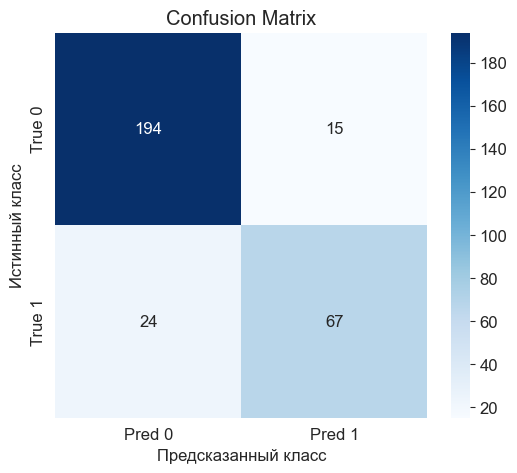

TN=194, FP=15
FN=24, TP=67


In [30]:
cm = confusion_matrix(y_test_clf, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.title('Confusion Matrix')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

print(f"TN={cm[0,0]}, FP={cm[0,1]}")
print(f"FN={cm[1,0]}, TP={cm[1,1]}")


---
## 5. Метрики регрессии


In [31]:
# Создаём данные для регрессии
X_reg, y_reg = make_regression(
    n_samples=500, n_features=10, n_informative=5,
    noise=20, random_state=RANDOM_STATE
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=RANDOM_STATE
)

model_reg = Ridge(random_state=RANDOM_STATE)
model_reg.fit(X_train_reg, y_train_reg)
y_pred_reg = model_reg.predict(X_test_reg)


### 5.1 MAE — Mean Absolute Error

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**Интерпретация:** Средняя абсолютная ошибка в единицах таргета.


In [32]:
mae = mean_absolute_error(y_test_reg, y_pred_reg)
print(f"MAE: {mae:.4f}")


MAE: 17.0494


### 5.2 MSE и RMSE

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

$$\text{RMSE} = \sqrt{\text{MSE}}$$

**MSE** сильнее штрафует за большие ошибки. **RMSE** в тех же единицах, что и таргет.


In [33]:
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")


MSE:  466.8045
RMSE: 21.6057


### 5.3 R² — коэффициент детерминации

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

**Интерпретация:** Доля дисперсии таргета, объясненная моделью.
- R² = 1 — идеальная модель
- R² = 0 — модель не лучше, чем предсказывать среднее
- R² < 0 — модель хуже, чем среднее (что-то пошло не так)


### Итоговая мини-практика
Соберите свой мини-эксперимент, опираясь на всё, что выше.
- Сформируйте датасет (можно использовать готовый synthetic из ноутбука).
- Выберите схему CV и минимум две метрики.
- Покажите влияние потенциальной утечки: модель с проблемным признаком и модель без него.
- В конце напишите 3 вывода: какую схему выбрали, какая метрика ключевая и что оказалось утечкой.


In [ ]:
# TODO: заполните пайплайн итоговой мини-практики
# Шаги: подготовка данных, выбор схемы CV, обучение модели, сравнение метрик
# Чтобы проверить себя, распечатывайте промежуточные результаты

# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import roc_auc_score
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# baseline_scores = []
# fixed_scores = []
# for train_idx, val_idx in cv.split(X, y):
#     ...
# print("Baseline AUC:", baseline_scores)
# print("Fixed AUC:", fixed_scores)


In [34]:
r2 = r2_score(y_test_reg, y_pred_reg)
print(f"R²: {r2:.4f}")


R²: 0.9094


---
### Упражнение 2: Полный пример с CV и метриками

Реализуйте кросс-валидацию вручную с использованием StratifiedKFold.


In [ ]:
# TODO: Реализуйте кросс-валидацию вручную с использованием StratifiedKFold
# Для каждого фолда:
# 1. Разделите данные
# 2. Обучите LogisticRegression
# 3. Посчитайте ROC-AUC, Precision, Recall
# 4. Выведите результаты

X_practice, y_practice = make_classification(
    n_samples=500, n_features=15, n_informative=8,
    n_classes=2, weights=[0.6, 0.4], random_state=RANDOM_STATE
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {'roc_auc': [], 'precision': [], 'recall': []}

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_practice, y_practice)):
    # ВАШ КОД ЗДЕСЬ
    pass

# Выведите средние значения метрик


In [ ]:
# SOLUTION
X_practice, y_practice = make_classification(
    n_samples=500, n_features=15, n_informative=8,
    n_classes=2, weights=[0.6, 0.4], random_state=RANDOM_STATE
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {'roc_auc': [], 'precision': [], 'recall': []}

print("Результаты по фолдам:")
print("-" * 50)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_practice, y_practice)):
    X_tr, X_val = X_practice[train_idx], X_practice[val_idx]
    y_tr, y_val = y_practice[train_idx], y_practice[val_idx]
    
    model = LogisticRegression(random_state=RANDOM_STATE)
    model.fit(X_tr, y_tr)
    
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    roc = roc_auc_score(y_val, y_pred_proba)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    
    results['roc_auc'].append(roc)
    results['precision'].append(prec)
    results['recall'].append(rec)
    
    print(f"Fold {fold_idx+1}: ROC-AUC={roc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}")

print("-" * 50)
print(f"Mean ROC-AUC:   {np.mean(results['roc_auc']):.4f} ± {np.std(results['roc_auc']):.4f}")
print(f"Mean Precision: {np.mean(results['precision']):.4f} ± {np.std(results['precision']):.4f}")
print(f"Mean Recall:    {np.mean(results['recall']):.4f} ± {np.std(results['recall']):.4f}")


---
## Что дальше?

Теперь вы знаете:
- Какую схему CV выбрать для разных типов данных
- Как избежать типичных утечек данных
- Какие метрики использовать и как их интерпретировать

**Следующий шаг:** `02_sklearn_pipelines.ipynb` — узнаете, как строить пайплайны sklearn, чтобы автоматически избегать утечек при предобработке.

**Также рекомендуем:**
- `boostings_101.ipynb` — подбор гиперпараметров бустингов
- `eda-feat-engeen.ipynb` — EDA и feature engineering


In [35]:
# Сравним KFold и StratifiedKFold
print("=== KFold ===")
for fold_idx, (train_idx, val_idx) in enumerate(KFold(n_splits=5).split(X_imb)):
    val_class_ratio = y_imb[val_idx].mean()
    print(f"Fold {fold_idx+1}: доля класса 1 в val = {val_class_ratio:.2%}")
print("\n=== StratifiedKFold ===")
for fold_idx, (train_idx, val_idx) in enumerate(StratifiedKFold(n_splits=5).split(X_imb, y_imb)):
    val_class_ratio = y_imb[val_idx].mean()
    print(f"Fold {fold_idx+1}: доля класса 1 в val = {val_class_ratio:.2%}")


=== KFold ===
Fold 1: доля класса 1 в val = 7.50%
Fold 2: доля класса 1 в val = 10.00%
Fold 3: доля класса 1 в val = 7.50%
Fold 4: доля класса 1 в val = 7.50%
Fold 5: доля класса 1 в val = 17.50%

=== StratifiedKFold ===
Fold 1: доля класса 1 в val = 10.00%
Fold 2: доля класса 1 в val = 10.00%
Fold 3: доля класса 1 в val = 10.00%
Fold 4: доля класса 1 в val = 10.00%
Fold 5: доля класса 1 в val = 10.00%
